# AI Multi-Disease Prediction

> Educational project notebook. Not a medical diagnosis tool.

This single file includes:
- Synthetic dataset generation (no upload needed)
- Multiple disease classes in one model
- Preprocessing, visualization, training, evaluation
- Single prediction (manual + dropdown)
- Bulk prediction CSV output

In [1]:
!pip -q install pandas numpy scikit-learn matplotlib seaborn ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 49.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)
sns.set_style('whitegrid')
print('Libraries loaded.')

Libraries loaded.


## 1) Generate Multi-Disease Dataset

Disease classes used:
- Common Cold
- Flu
- Allergy
- Migraine
- Food Poisoning
- Skin Infection
- Asthma
- Hypertension Risk
- Diabetes Risk
- Healthy

In [3]:
n = 5000
age = np.random.randint(5, 85, n)
sex = np.random.choice(['male', 'female'], n)
temperature_f = np.round(np.random.normal(98.6, 1.3, n), 1)
systolic_bp = np.random.randint(95, 185, n)
glucose = np.random.randint(70, 240, n)

cough = np.random.binomial(1, 0.35, n)
fever = np.random.binomial(1, 0.33, n)
headache = np.random.binomial(1, 0.30, n)
fatigue = np.random.binomial(1, 0.30, n)
runny_nose = np.random.binomial(1, 0.28, n)
sore_throat = np.random.binomial(1, 0.26, n)
nausea = np.random.binomial(1, 0.18, n)
vomiting = np.random.binomial(1, 0.12, n)
skin_rash = np.random.binomial(1, 0.11, n)
wheezing = np.random.binomial(1, 0.10, n)

disease = []
for i in range(n):
    if fever[i] and cough[i] and fatigue[i] and temperature_f[i] > 100.0:
        disease.append('Flu')
    elif runny_nose[i] and sore_throat[i] and cough[i] and fever[i] == 0:
        disease.append('Common Cold')
    elif runny_nose[i] and headache[i] and fever[i] == 0 and skin_rash[i] == 0:
        disease.append('Allergy')
    elif headache[i] and nausea[i] and fever[i] == 0:
        disease.append('Migraine')
    elif nausea[i] and vomiting[i] and fever[i]:
        disease.append('Food Poisoning')
    elif skin_rash[i]:
        disease.append('Skin Infection')
    elif wheezing[i] and cough[i]:
        disease.append('Asthma')
    elif systolic_bp[i] >= 145 and age[i] > 35:
        disease.append('Hypertension Risk')
    elif glucose[i] >= 150 and age[i] > 30:
        disease.append('Diabetes Risk')
    else:
        disease.append('Healthy')

df = pd.DataFrame({
    'age': age,
    'sex': sex,
    'temperature_f': temperature_f,
    'systolic_bp': systolic_bp,
    'glucose': glucose,
    'cough': cough,
    'fever': fever,
    'headache': headache,
    'fatigue': fatigue,
    'runny_nose': runny_nose,
    'sore_throat': sore_throat,
    'nausea': nausea,
    'vomiting': vomiting,
    'skin_rash': skin_rash,
    'wheezing': wheezing,
    'predicted_disease_label': disease
})

df.to_csv('synthetic_all_diseases_dataset.csv', index=False)
print('Generated dataset:', df.shape)
df.head()

Generated dataset: (5000, 16)


,age,sex,temperature_f,systolic_bp,glucose,cough,fever,headache,fatigue,runny_nose,sore_throat,nausea,vomiting,skin_rash,wheezing,predicted_disease_label
0,56,female,99.4,123,122,0,1,0,0,0,0,0,0,1,0,Skin Infection
1,19,male,98.3,148,197,0,0,0,0,0,0,0,0,0,0,Healthy
2,76,female,99.1,121,134,0,0,1,0,1,0,0,0,0,1,Allergy
3,65,female,98.2,139,133,0,0,1,1,0,0,0,0,1,0,Skin Infection
4,25,female,99.1,181,137,1,1,1,0,0,0,0,0,0,0,Healthy


## 2) Preprocessing + Train/Test Split

In [4]:
X = df.drop(columns=['predicted_disease_label'])
y = df['predicted_disease_label']

categorical_cols = ['sex']
numeric_cols = [c for c in X.columns if c not in categorical_cols]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', 'passthrough', numeric_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train:', X_train.shape, ' Test:', X_test.shape)
print('\nClass counts:\n', y.value_counts())

Train: (4000, 15)  Test: (1000, 15)

Class counts:
 predicted_disease_label
Healthy              1993
Hypertension Risk    1052
Diabetes Risk         785
Skin Infection        550
Allergy               208
Migraine              145
Asthma                124
Common Cold            71
Food Poisoning         45
Flu                    27
Name: count, dtype: int64


## 3) Visualizations

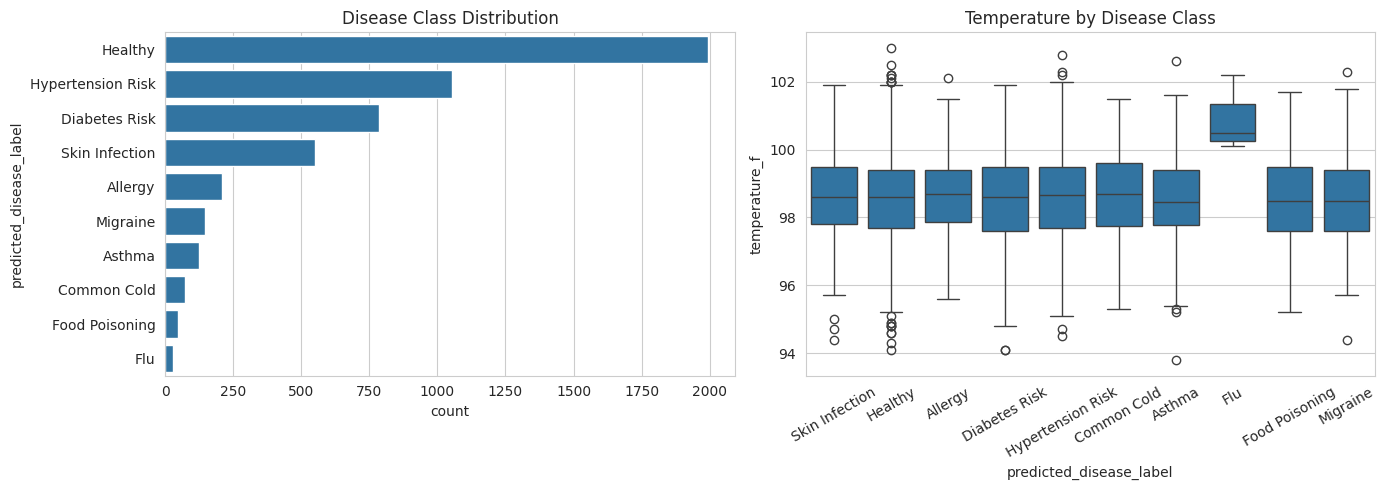

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, y='predicted_disease_label', order=df['predicted_disease_label'].value_counts().index, ax=axes[0])
axes[0].set_title('Disease Class Distribution')

sns.boxplot(data=df, x='predicted_disease_label', y='temperature_f', ax=axes[1])
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_title('Temperature by Disease Class')
plt.tight_layout()
plt.show()

## 4) Train AI Model

In [6]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=350, random_state=42))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred))

Accuracy: 0.971

Classification Report:

                   precision    recall  f1-score   support

          Allergy       1.00      1.00      1.00        42
           Asthma       0.96      0.92      0.94        25
      Common Cold       1.00      0.14      0.25        14
    Diabetes Risk       0.96      1.00      0.98       157
              Flu       0.00      0.00      0.00         5
   Food Poisoning       0.00      0.00      0.00         9
          Healthy       0.97      1.00      0.99       399
Hypertension Risk       0.97      1.00      0.98       210
         Migraine       1.00      0.97      0.98        29
   Skin Infection       0.97      1.00      0.99       110

         accuracy                           0.97      1000
        macro avg       0.78      0.70      0.71      1000
     weighted avg       0.96      0.97      0.96      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


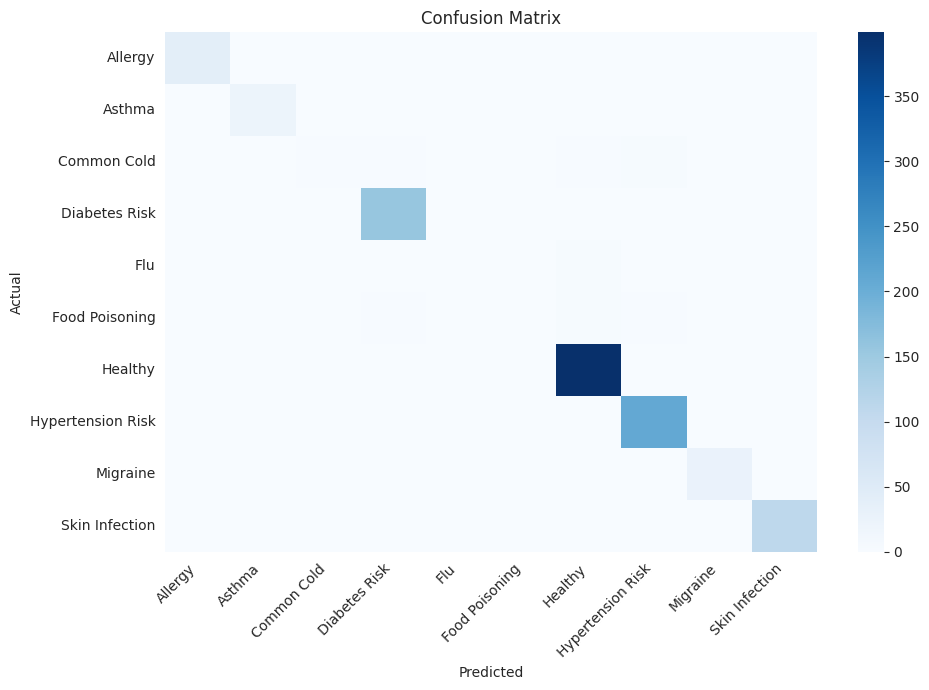

In [7]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, cmap='Blues', annot=False, xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 5) Single Prediction (Manual)

In [8]:
single_case = pd.DataFrame([{
    'age': 42,
    'sex': 'male',
    'temperature_f': 101.8,
    'systolic_bp': 130,
    'glucose': 110,
    'cough': 1,
    'fever': 1,
    'headache': 1,
    'fatigue': 1,
    'runny_nose': 0,
    'sore_throat': 1,
    'nausea': 0,
    'vomiting': 0,
    'skin_rash': 0,
    'wheezing': 0
}])

pred = model.predict(single_case)[0]
proba = model.predict_proba(single_case)[0]
classes = model.named_steps['classifier'].classes_
print('Predicted disease:', pred)
print('\nTop probabilities:')
for c, p in sorted(zip(classes, proba), key=lambda x: x[1], reverse=True)[:5]:
    print(f'{c:20s} -> {p:.3f}')

Predicted disease: Healthy

Top probabilities:
Healthy              -> 0.714
Flu                  -> 0.103
Diabetes Risk        -> 0.054
Common Cold          -> 0.043
Hypertension Risk    -> 0.029


## 6) Single Prediction (Dropdown UI)

In [9]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

age_w = widgets.IntSlider(value=30, min=5, max=85, description='Age')
sex_w = widgets.Dropdown(options=['male', 'female'], value='male', description='Sex')
temp_w = widgets.FloatSlider(value=98.6, min=95.0, max=105.0, step=0.1, description='Temp(F)')
bp_w = widgets.IntSlider(value=120, min=90, max=190, description='SBP')
glu_w = widgets.IntSlider(value=100, min=60, max=260, description='Glucose')

def yn(name):
    return widgets.Dropdown(options=[('No', 0), ('Yes', 1)], value=0, description=name)

cough_w = yn('Cough')
fever_w = yn('Fever')
head_w = yn('Headache')
fatigue_w = yn('Fatigue')
rn_w = yn('RunnyNose')
st_w = yn('SoreThroat')
nau_w = yn('Nausea')
vom_w = yn('Vomiting')
rash_w = yn('SkinRash')
wheeze_w = yn('Wheezing')

btn = widgets.Button(description='Predict Disease', button_style='success')
out = widgets.Output()

def run(_):
    with out:
        clear_output()
        row = pd.DataFrame([{
            'age': age_w.value, 'sex': sex_w.value, 'temperature_f': temp_w.value,
            'systolic_bp': bp_w.value, 'glucose': glu_w.value,
            'cough': cough_w.value, 'fever': fever_w.value, 'headache': head_w.value,
            'fatigue': fatigue_w.value, 'runny_nose': rn_w.value, 'sore_throat': st_w.value,
            'nausea': nau_w.value, 'vomiting': vom_w.value, 'skin_rash': rash_w.value,
            'wheezing': wheeze_w.value
        }])
        pred = model.predict(row)[0]

        if pred == 'Healthy':
            color = 'green'
        else:
            color = 'red'
        display(HTML(f'<p style="font-size: xx-large; color: {color};">Predicted disease: <b>{pred}</b></p>'))

btn.on_click(run)
display(widgets.VBox([
    age_w, sex_w, temp_w, bp_w, glu_w, cough_w, fever_w, head_w, fatigue_w,
    rn_w, st_w, nau_w, vom_w, rash_w, wheeze_w, btn, out
]))

## 7) Bulk Prediction Output

In [10]:
m = 300
bulk = pd.DataFrame({
    'age': np.random.randint(5, 85, m),
    'sex': np.random.choice(['male', 'female'], m),
    'temperature_f': np.round(np.random.uniform(96.5, 104.5, m), 1),
    'systolic_bp': np.random.randint(90, 190, m),
    'glucose': np.random.randint(65, 250, m),
    'cough': np.random.binomial(1, 0.35, m),
    'fever': np.random.binomial(1, 0.33, m),
    'headache': np.random.binomial(1, 0.30, m),
    'fatigue': np.random.binomial(1, 0.30, m),
    'runny_nose': np.random.binomial(1, 0.28, m),
    'sore_throat': np.random.binomial(1, 0.26, m),
    'nausea': np.random.binomial(1, 0.18, m),
    'vomiting': np.random.binomial(1, 0.12, m),
    'skin_rash': np.random.binomial(1, 0.11, m),
    'wheezing': np.random.binomial(1, 0.10, m)
})

bulk['predicted_disease'] = model.predict(bulk)
bulk.to_csv('bulk_all_diseases_predictions_300.csv', index=False)
print('Saved: bulk_all_diseases_predictions_300.csv')
bulk.head(10)

Saved: bulk_all_diseases_predictions_300.csv


,age,sex,temperature_f,systolic_bp,glucose,cough,fever,headache,fatigue,runny_nose,sore_throat,nausea,vomiting,skin_rash,wheezing,predicted_disease
0,45,male,96.8,99,94,0,0,1,0,0,0,0,0,0,0,Healthy
1,5,male,101.8,179,142,0,0,0,0,0,0,0,0,0,0,Healthy
2,67,male,99.0,103,197,0,0,0,0,0,0,0,0,0,0,Diabetes Risk
3,39,male,103.5,178,232,0,1,0,0,0,0,0,0,0,0,Hypertension Risk
4,52,female,98.8,100,213,0,0,0,1,1,0,0,0,0,0,Diabetes Risk
5,43,male,103.8,108,171,0,1,0,0,0,1,0,0,0,0,Diabetes Risk
6,24,female,101.4,140,72,0,0,0,1,0,0,1,0,0,0,Healthy
7,81,female,101.7,117,70,1,0,0,0,0,0,0,0,1,0,Skin Infection
8,42,female,103.6,116,154,0,0,1,1,1,0,0,0,0,1,Allergy
9,27,female,104.4,100,122,1,0,0,1,1,0,0,0,0,0,Healthy
